# Data Preprocessing for multi-task LSTM
This notebook prepares the hospital microgrid data for training an LSTM model that predicts energy demand, outages, and alert levels.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import json
from pathlib import Path
from sklearn.preprocessing import MinMaxScaler
from sklearn.utils.class_weight import compute_class_weight
import os

# Settings
os.makedirs('../models/preprocessing', exist_ok=True)

## Section 1 — Load & Select Features

In [3]:
df = pd.read_csv('../data/master_dataset.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.set_index('timestamp', inplace=True)

input_features = [
    'net_solar_kw', 'net_wind_kw', 'grid_available_kw', 'total_supply_kw',
    'total_hospital_kw', 'energy_balance_kw', 'avg_battery_pct', 'min_battery_pct',
    'temperature_2m', 'cloud_cover', 'windspeed_10m', 'precipitation',
    'hour', 'is_weekend', 'is_daytime', 'renewable_fraction', 'is_trading'
]

# Season encoding
df['is_winter'] = (df['season'] == 'winter').astype(int)
df['is_spring'] = (df['season'] == 'spring').astype(int)
df['is_summer'] = (df['season'] == 'summer').astype(int)
df['is_autumn'] = (df['season'] == 'autumn').astype(int)

input_features += ['is_winter', 'is_spring', 'is_summer', 'is_autumn']

# Alert encoding
alert_map = {'NORMAL': 0, 'WARNING': 1, 'CRITICAL': 2}
df['alert_encoded'] = df['alert_level'].map(alert_map)

print(f'Final Features: {input_features}')
print(f'Shape: {df[input_features].shape}')

Final Features: ['net_solar_kw', 'net_wind_kw', 'grid_available_kw', 'total_supply_kw', 'total_hospital_kw', 'energy_balance_kw', 'avg_battery_pct', 'min_battery_pct', 'temperature_2m', 'cloud_cover', 'windspeed_10m', 'precipitation', 'hour', 'is_weekend', 'is_daytime', 'renewable_fraction', 'is_trading', 'is_winter', 'is_spring', 'is_summer', 'is_autumn']
Shape: (35039, 21)


## Section 2 — Handle Class Imbalance

In [4]:
print('Alert Distribution:')
print(df['alert_encoded'].value_counts())

classes = np.unique(df['alert_encoded'])
weights = compute_class_weight(class_weight='balanced', classes=classes, y=df['alert_encoded'])
class_weights = {int(c): float(w) for c, w in zip(classes, weights)}

print(f'Class Weights: {class_weights}')
with open('../models/preprocessing/class_weights.json', 'w') as f:
    json.dump(class_weights, f)
print('Saved class weights to models/preprocessing/class_weights.json')

Alert Distribution:
alert_encoded
0    34819
2      166
1       54
Name: count, dtype: int64
Class Weights: {0: 0.3354394631283686, 1: 216.29012345679013, 2: 70.35943775100401}
Saved class weights to models/preprocessing/class_weights.json


## Section 3 — Train / Validation / Test Split

Train: 2022-01-01 00:00:00 to 2023-05-26 23:00:00 (24527 rows)
Val:   2023-05-26 23:30:00 to 2023-09-13 10:30:00 (5255 rows)
Test:  2023-09-13 11:00:00 to 2023-12-31 23:00:00 (5257 rows)


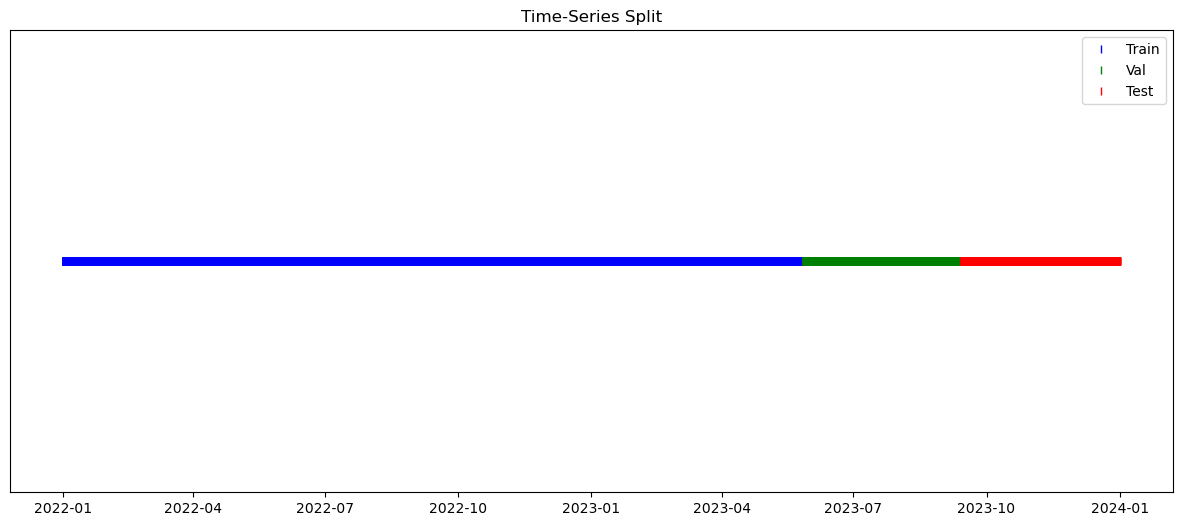

In [5]:
n = len(df)
train_size = int(n * 0.7)
val_size = int(n * 0.15)

train_df = df.iloc[:train_size]
val_df = df.iloc[train_size:train_size+val_size]
test_df = df.iloc[train_size+val_size:]

print(f'Train: {train_df.index.min()} to {train_df.index.max()} ({len(train_df)} rows)')
print(f'Val:   {val_df.index.min()} to {val_df.index.max()} ({len(val_df)} rows)')
print(f'Test:  {test_df.index.min()} to {test_df.index.max()} ({len(test_df)} rows)')

plt.figure(figsize=(15, 6))
plt.plot(train_df.index, [1]*len(train_df), '|', label='Train', color='blue')
plt.plot(val_df.index, [1]*len(val_df), '|', label='Val', color='green')
plt.plot(test_df.index, [1]*len(test_df), '|', label='Test', color='red')
plt.legend()
plt.title('Time-Series Split')
plt.yticks([])
plt.show()

## Section 4 — Scaling

Saved scaler to models/preprocessing/scaler.pkl


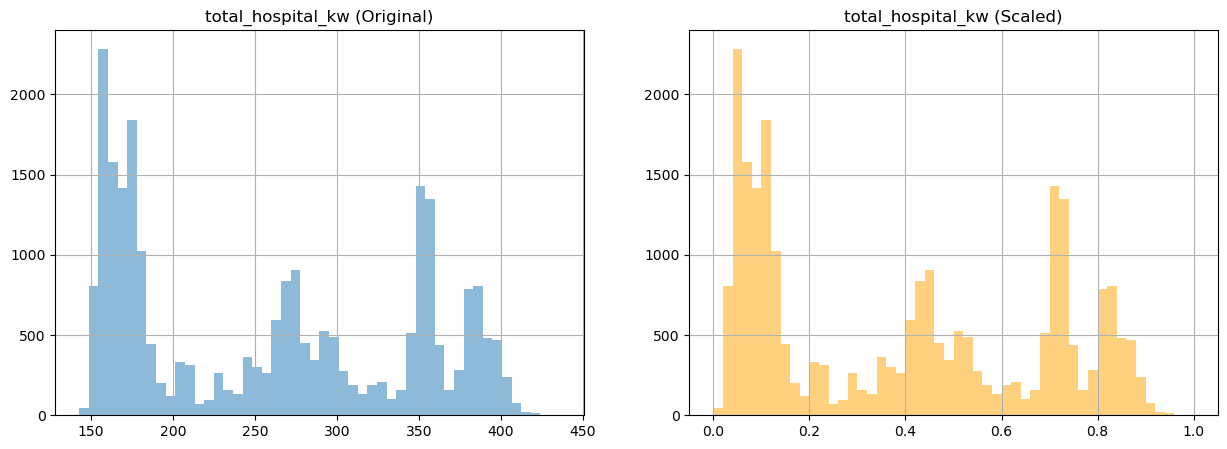

In [6]:
scaler = MinMaxScaler()
scaler.fit(train_df[input_features])

train_scaled = scaler.transform(train_df[input_features])
val_scaled = scaler.transform(val_df[input_features])
test_scaled = scaler.transform(test_df[input_features])

joblib.dump(scaler, '../models/preprocessing/scaler.pkl')
print('Saved scaler to models/preprocessing/scaler.pkl')

# Visual Check
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
train_df['total_hospital_kw'].hist(ax=axes[0], bins=50, alpha=0.5, label='Original')
axes[0].set_title('total_hospital_kw (Original)')

pd.Series(train_scaled[:, 4]).hist(ax=axes[1], bins=50, alpha=0.5, color='orange', label='Scaled')
axes[1].set_title('total_hospital_kw (Scaled)')
plt.show()

## Section 5 — Build Sequences

In [7]:
def create_sequences(scaled_data, raw_df, seq_length=48, pred_length=8):
    X = []
    y_demand = []
    y_anomaly = []
    y_alert = []
    
    # We need to use the raw_df for labels as they are not all in input_features
    for i in range(len(scaled_data) - seq_length - pred_length + 1):
        # Input: [i : i+48]
        X.append(scaled_data[i : i+seq_length])
        
        # Predicted index: [i+48 : i+48+8]
        # Regression: total_hospital_kw
        y_demand.append(raw_df['total_hospital_kw'].iloc[i+seq_length : i+seq_length+pred_length].values)
        
        # Binary: is_outage in next 8 steps
        outage_present = raw_df['is_outage'].iloc[i+seq_length : i+seq_length+pred_length].any()
        y_anomaly.append(1 if outage_present else 0)
        
        # Multiclass: alert_encoded at the end of pred window (i+seq_length+pred_length-1)
        y_alert.append(raw_df['alert_encoded'].iloc[i+seq_length+pred_length-1])
        
    return np.array(X), np.array(y_demand), np.array(y_anomaly), np.array(y_alert)

X_train, y_demand_train, y_anomaly_train, y_alert_train = create_sequences(train_scaled, train_df)
X_val, y_demand_val, y_anomaly_val, y_alert_val = create_sequences(val_scaled, val_df)
X_test, y_demand_test, y_anomaly_test, y_alert_test = create_sequences(test_scaled, test_df)

print(f'X_train shape: {X_train.shape}')
print(f'y_demand_train shape: {y_demand_train.shape}')

for split, data in zip(['train', 'val', 'test'], 
                       [[X_train, y_demand_train, y_anomaly_train, y_alert_train],
                        [X_val, y_demand_val, y_anomaly_val, y_alert_val],
                        [X_test, y_demand_test, y_anomaly_test, y_alert_test]]):
    np.save(f'../models/preprocessing/X_{split}.npy', data[0])
    np.save(f'../models/preprocessing/y_demand_{split}.npy', data[1])
    np.save(f'../models/preprocessing/y_anomaly_{split}.npy', data[2])
    np.save(f'../models/preprocessing/y_alert_{split}.npy', data[3])

X_train shape: (24472, 48, 21)
y_demand_train shape: (24472, 8)


## Section 6 — Verify Sequences

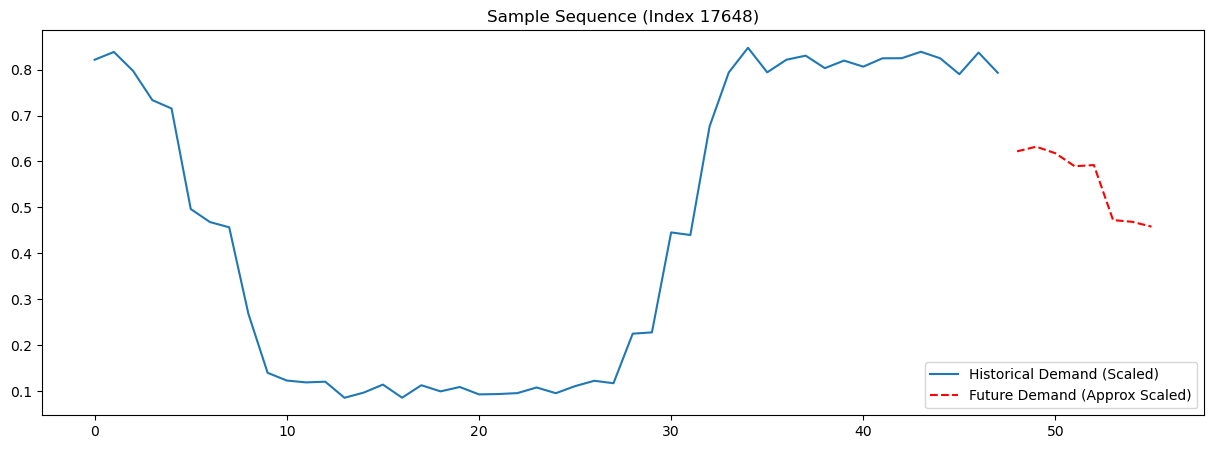

y_anomaly: 0
y_alert: 0
Any NaNs in X_train: False


In [8]:
idx = np.random.randint(0, len(X_train))
plt.figure(figsize=(15, 5))
plt.plot(range(48), X_train[idx, :, 4], label='Historical Demand (Scaled)')
# We need to scale the target demand if we want to plot on same axis, 
# or just plot raw but here X is scaled. 
# Let's just plot the pattern.
plt.plot(range(48, 56), y_demand_train[idx] / 600.0, 'r--', label='Future Demand (Approx Scaled)')
plt.title(f'Sample Sequence (Index {idx})')
plt.legend()
plt.show()

print(f'y_anomaly: {y_anomaly_train[idx]}')
print(f'y_alert: {y_alert_train[idx]}')
print(f'Any NaNs in X_train: {np.isnan(X_train).any()}')